# 04 - Processing and Integration

Joins the cleaned datasets, builds analytical features, and writes
the core analytical layer. **Analytical accounting rule:** revenue,
sales and performance analytics use **completed orders only**;
cancelled orders stay in `orders_processed.csv` (flagged with
`is_completed = False`) for cancellation-behaviour analysis.


In [1]:
import sys
from pathlib import Path
import pandas as pd

sys.path.insert(0, str(Path.cwd()))
import nb_common

# ------------------------------------------------------------------
# Run mode:
#   "quick" -> demo-scale data (~20k orders) in notebook/outputs/
#   "full"  -> full SRS scale (1M lines) in the canonical repo dirs
# ------------------------------------------------------------------
MODE = "quick"

paths = nb_common.setup_paths(MODE)
nb_common.ensure_config(paths)
mk = nb_common.markers(paths)

pd.options.display.max_columns = 20
print(f"MODE: {MODE}")
print(f"raw       : {paths['raw']}")
print(f"processed : {paths['processed']}")


MODE: quick
raw       : /home/user/Techwizz/notebook/outputs/quick/raw
processed : /home/user/Techwizz/notebook/outputs/quick/processed


In [2]:
if not nb_common.step_done(*mk['generation']):
    from generate_dineiq_data import generate
    generate(raw_dir=paths['raw'], config_path=paths['config'])
if not nb_common.step_done(*mk['cleaning']):
    import clean_dineiq_data
    clean_dineiq_data.main(
        raw_dir=paths['raw'], processed_dir=paths['processed'],
        reports_dir=paths['reports'], quarantine_dir=paths['quarantine'],
        config_path=paths['config'])

In [3]:
import process_dineiq_data

if not nb_common.step_done(*mk['processing']):
    process_dineiq_data.main(
        processed_dir=paths['processed'],
        output_dir=paths['analytics'],
        reports_dir=paths['reports'],
    )
else:
    print('Core analytics already exist - skipping.')

DineIQ Analytics - Data Processing & Integration
Input : /home/user/Techwizz/notebook/outputs/quick/processed
Output: /home/user/Techwizz/notebook/outputs/quick/processed/analytics

Loading locations.csv...
  Rows: 20 | Columns: 4
Loading restaurants.csv...
  Rows: 20 | Columns: 5
Loading menu_categories.csv...
  Rows: 10 | Columns: 2
Loading menu_items.csv...
  Rows: 150 | Columns: 9
Loading customers.csv...
  Rows: 8,000 | Columns: 11

Creating enriched menu reference...
  Saved: menu_enriched.csv (150 rows)

Processing orders...
Loading orders.csv...
  Rows: 19,980 | Columns: 14


  Saved: orders_processed.csv (19,980 rows)

Processing order items...
Loading order_items.csv...
  Rows: 199,440 | Columns: 7


  Saved: order_items_integrated.csv (199,440 rows)

Creating integrated order dataset...


  Saved: orders_integrated.csv (19,980 rows)

Creating customer analytics...
  Saved: customer_analytics.csv (8,000 rows)

Creating menu item performance...
  Saved: menu_item_performance.csv (150 rows)

Creating restaurant performance...
  Saved: restaurant_performance.csv (20 rows)

Creating sales trend analytics...


  Saved: daily_sales.csv (365 rows)
  Saved: monthly_sales.csv (12 rows)

Creating channel analytics...
  Saved: channel_analysis.csv (4 rows)

Creating time-pattern analytics...
  Saved: time_pattern_analysis.csv (35 rows)

Processing wastage...
Loading wastage.csv...
  Rows: 10,000 | Columns: 7
  Saved: wastage_integrated.csv (10,000 rows)
  Saved: wastage_item_analysis.csv (150 rows)

Processing ratings...
Loading ratings.csv...
  Rows: 19,868 | Columns: 8
  Saved: ratings_integrated.csv (19,868 rows)
  Saved: rating_item_analysis.csv (150 rows)

Processing inventory...
Loading inventory.csv...
  Rows: 10,000 | Columns: 10


  Saved: inventory_integrated.csv (10,000 rows)

Creating pricing analytics...
Loading pricing_history.csv...
  Rows: 272 | Columns: 7
  Saved: pricing_analysis.csv (272 rows)

Creating promotion usage summary...
Loading promotions.csv...
  Rows: 120 | Columns: 11
  Saved: promotion_usage.csv (120 rows)

Creating processing summary...

DATA PROCESSING & INTEGRATION COMPLETE
Analytics output: /home/user/Techwizz/notebook/outputs/quick/processed/analytics
Processing report: /home/user/Techwizz/notebook/outputs/quick/reports/processing_summary.csv

Generated analytical datasets:
  - channel_analysis.csv
  - customer_analytics.csv
  - daily_sales.csv
  - inventory_integrated.csv
  - menu_enriched.csv
  - menu_item_performance.csv
  - monthly_sales.csv
  - order_items_integrated.csv
  - orders_integrated.csv
  - orders_processed.csv
  - pricing_analysis.csv
  - promotion_usage.csv
  - rating_item_analysis.csv
  - ratings_integrated.csv
  - restaurant_performance.csv
  - time_pattern_analysi

In [4]:
print('--- Core analytical outputs ---')
import os
rows = []
for f in sorted(paths['analytics'].glob('*.csv')):
    if f.name in ('advanced_analytics_summary.csv',):  # produced by notebook 05
        continue
    rows.append({'file': f.name, 'rows': len(pd.read_csv(f, low_memory=False))})
pd.DataFrame(rows)

--- Core analytical outputs ---


,file,rows
0,channel_analysis.csv,4
1,customer_analytics.csv,8000
2,daily_sales.csv,365
3,inventory_integrated.csv,10000
4,menu_enriched.csv,150
5,menu_item_performance.csv,150
6,monthly_sales.csv,12
7,order_items_integrated.csv,199440
8,orders_integrated.csv,19980
9,orders_processed.csv,19980


In [5]:
orders = pd.read_csv(paths['analytics'] / 'orders_processed.csv', low_memory=False)
print('completed:', int(orders['is_completed'].sum()), '| cancelled:', int((~orders['is_completed']).sum()),
      '| promo orders:', int(orders['is_promo_order'].sum()))
orders.head(5)

completed: 15858 | cancelled: 4122 | promo orders: 2879


,order_id,customer_id,restaurant_id,order_date,order_time,order_status,order_channel,payment_method,promotion_id,subtotal,...,order_month,order_month_name,order_week,order_day,day_of_week,is_weekend,order_hour,time_period,discount_rate_percentage,is_high_value_order
0,1,5366,6,2025-05-25,13:14:00,Cancelled,Takeaway,Cash,94.0,17245.58,...,5,May,21,25,Sunday,True,13,Lunch Peak,12.332145,False
1,2,4198,3,2025-07-14,17:37:00,Completed,Website/App,Online Wallet,NaN,10075.18,...,7,July,29,14,Monday,False,17,Afternoon,0.000000,False
2,3,7106,2,2025-06-10,20:52:00,Completed,Dine-in,Online Wallet,NaN,16577.12,...,6,June,24,10,Tuesday,False,20,Dinner Peak,15.000012,False
3,4,4499,10,2025-06-09,20:23:00,Cancelled,Third-party Delivery,Card,NaN,4278.88,...,6,June,24,9,Monday,False,20,Dinner Peak,10.000047,False
4,5,211,18,2025-04-26,13:59:00,Completed,Takeaway,Online Wallet,NaN,7136.42,...,4,April,17,26,Saturday,True,13,Lunch Peak,0.000000,False


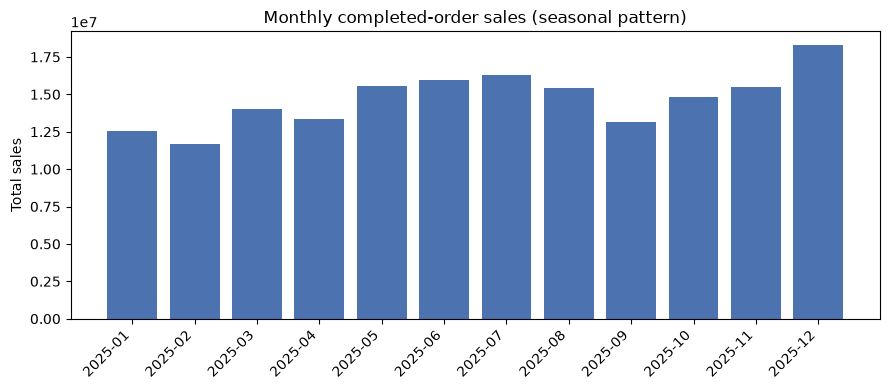

In [6]:
import matplotlib.pyplot as plt

monthly = pd.read_csv(paths['analytics'] / 'monthly_sales.csv', low_memory=False)
plt.figure(figsize=(9, 4))
plt.bar(monthly['month'], monthly['total_sales'], color='#4C72B0')
plt.xticks(rotation=45, ha='right')
plt.title('Monthly completed-order sales (seasonal pattern)')
plt.ylabel('Total sales')
plt.tight_layout()
plt.show()

**Next:** `05_advanced_analytics_and_ml.ipynb` - the SRS
intelligence layer (RFM, menu classes, forecasting, churn, ...).
